# Notebook 11 — CLV Regression (Multi-Model + Selection)

**Inputs:** `outputs/transaction_features.parquet`, `outputs/train.parquet`, `outputs/val.parquet`, `outputs/test.parquet`, `outputs/kkbox_features.parquet`, Optuna studies  
**Outputs:** `outputs/clv_model.pkl`, `outputs/clv_predictions.parquet`, `outputs/clv_model_comparison.csv`

**Context:** For KKBox, CLV = expected subscription revenue going forward.  
We proxy this as the annualised historical payment rate:  
`CLV = total_paid / (days_as_member / 30) × 12`  
This represents the yearly predicted revenue for each customer.

**Carried-forward guardrails:**
- Column names normalised at load time (spaces/hyphens → underscores)
- 99th-percentile CLV cap computed from **train non-churned only**, then applied to val/test
- Ridge alpha selected on val set only (not test)
- XGB/LGBM use Optuna best params from churn study as starting point — classification-specific keys (`scale_pos_weight`, `class_weight`, `metric`, `eval_metric`, `early_stopping_rounds`) stripped before regression reuse
- Ridge uses `scaler.pkl` fit on train (from notebook 07) — no re-fit on CLV subset to prevent leakage

In [1]:
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")
ROOT    = Path("..").resolve()
OUTPUTS = ROOT / "outputs"
print("Project root:", ROOT)

Project root: C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction


In [2]:
def load_split(path):
    df = pd.read_parquet(path)
    df.columns = [c.replace(" ", "_").replace("-", "_") for c in df.columns]
    return df

# Load Optuna studies for best hyperparams (saved in notebook 08)
study_xgb  = joblib.load(OUTPUTS / "optuna_xgb_study.pkl")
study_lgbm = joblib.load(OUTPUTS / "optuna_lgbm_study.pkl")

# Load scaler (fit on train in notebook 07) for Ridge
scaler = joblib.load(OUTPUTS / "scaler.pkl")

print("XGB  best churn params:", study_xgb.best_params)
print("LGBM best churn params:", study_lgbm.best_params)

XGB  best churn params: {'n_estimators': 413, 'max_depth': 8, 'learning_rate': 0.09063243761985919, 'subsample': 0.9412740335607451, 'colsample_bytree': 0.7589746620940012, 'min_child_weight': 7}
LGBM best churn params: {'n_estimators': 540, 'num_leaves': 98, 'learning_rate': 0.08653948624452329, 'min_child_samples': 53, 'feature_fraction': 0.7080202400021893, 'bagging_fraction': 0.9977985318643916}


## Section 1 — Compute CLV Target

In [3]:
# Load transaction features (source of truth for total_paid and days_as_member)
tx = pd.read_parquet(OUTPUTS / "transaction_features.parquet")[["msno", "total_paid", "days_as_member"]]

# Load split parquets for is_churn labels and model features
train = load_split(OUTPUTS / "train.parquet")
val   = load_split(OUTPUTS / "val.parquet")
test  = load_split(OUTPUTS / "test.parquet")

TARGET       = "is_churn"
FEATURE_COLS = [c for c in train.columns if c not in ("msno", TARGET)]

def compute_clv(split_df, tx_df):
    """Merge CLV target from tx_df into split_df."""
    merged = split_df[["msno", TARGET]].merge(tx_df, on="msno", how="left")
    # Filter: non-churned only, days_as_member > 0 (avoid division by zero)
    mask = (merged[TARGET] == 0) & (merged["days_as_member"] > 0)
    sub  = merged[mask].copy()
    sub["clv_raw"] = sub["total_paid"] / (sub["days_as_member"] / 30) * 12
    return sub

train_clv = compute_clv(train, tx)
val_clv   = compute_clv(val,   tx)
test_clv  = compute_clv(test,  tx)

# CLV cap: 99th percentile of TRAIN non-churned only — no val/test leakage
clv_cap = train_clv["clv_raw"].quantile(0.99)
for df in [train_clv, val_clv, test_clv]:
    df["clv"] = df["clv_raw"].clip(upper=clv_cap)

print("Non-churned customer counts:")
print("  Train : %s" % f"{len(train_clv):,}")
print("  Val   : %s" % f"{len(val_clv):,}")
print("  Test  : %s" % f"{len(test_clv):,}")
print("CLV cap (99th pct, from train): %.2f" % clv_cap)
print("\nCLV distribution (train, after cap):")
print(train_clv["clv"].describe().round(2).to_string())

Non-churned customer counts:
  Train : 675,634
  Val   : 92,954
  Test  : 113,452
CLV cap (99th pct, from train): 2848.35

CLV distribution (train, after cap):
count    675634.00
mean       1598.46
std         364.66
min          50.28
25%        1289.61
50%        1659.70
75%        1833.27
max        2848.35


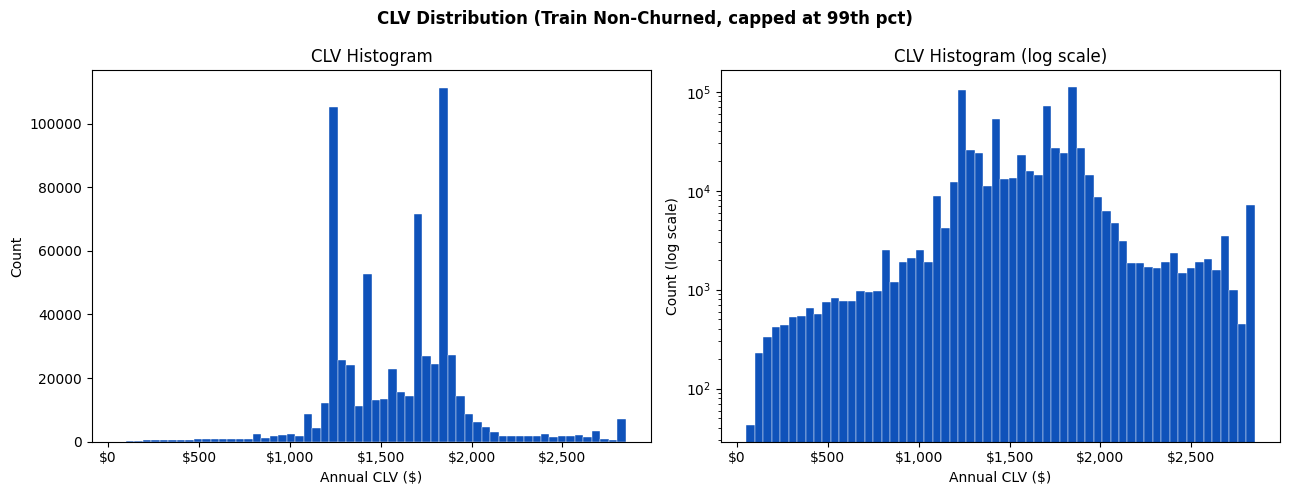

Median CLV       : $1659.70
90th pct CLV     : $1918.16
99th pct CLV cap : $2848.35
Saved: outputs/11_clv_distribution.png


In [4]:
# CLV distribution — histogram, log scale
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("CLV Distribution (Train Non-Churned, capped at 99th pct)",
             fontsize=12, fontweight="bold")

ax = axes[0]
ax.hist(train_clv["clv"], bins=60, color="#0F52BA", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Annual CLV ($)")
ax.set_ylabel("Count")
ax.set_title("CLV Histogram")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: "$%s" % f"{int(x):,}"))

ax = axes[1]
ax.hist(train_clv["clv"], bins=60, color="#0F52BA", edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("Annual CLV ($)")
ax.set_ylabel("Count (log scale)")
ax.set_title("CLV Histogram (log scale)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: "$%s" % f"{int(x):,}"))

plt.tight_layout()
plt.savefig(OUTPUTS / "11_clv_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Median CLV       : $%.2f" % train_clv["clv"].median())
print("90th pct CLV     : $%.2f" % train_clv["clv"].quantile(0.90))
print("99th pct CLV cap : $%.2f" % clv_cap)
print("Saved: outputs/11_clv_distribution.png")

In [5]:
# Build feature matrices for non-churned subsets only
def get_Xy(split_df, clv_df):
    """Filter split to non-churned rows (matching clv_df) and extract X, y."""
    sub = split_df[split_df["msno"].isin(clv_df["msno"])].copy()
    sub = sub.merge(clv_df[["msno", "clv"]], on="msno", how="inner")
    X = sub[FEATURE_COLS].values.astype(np.float32)
    y = sub["clv"].values.astype(np.float32)
    return X, y, sub["msno"].values

X_tr, y_tr, msno_tr = get_Xy(train, train_clv)
X_va, y_va, msno_va = get_Xy(val,   val_clv)
X_te, y_te, msno_te = get_Xy(test,  test_clv)

# Scaled versions for Ridge (use scaler fit on full train in nb07)
X_tr_sc = scaler.transform(X_tr)
X_va_sc = scaler.transform(X_va)
X_te_sc = scaler.transform(X_te)

print("Feature matrix shapes (non-churned only):")
print("  Train : %s x %d" % (f"{X_tr.shape[0]:,}", X_tr.shape[1]))
print("  Val   : %s x %d" % (f"{X_va.shape[0]:,}", X_va.shape[1]))
print("  Test  : %s x %d" % (f"{X_te.shape[0]:,}", X_te.shape[1]))

Feature matrix shapes (non-churned only):
  Train : 675,634 x 35
  Val   : 92,954 x 35
  Test  : 113,452 x 35


## Section 2 — Four Regression Models

In [6]:
def regression_metrics(y_true, y_pred, label=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if label:
        print("%s — RMSE=$%.2f  MAE=$%.2f  R²=%.4f" % (label, rmse, mae, r2))
    return {"RMSE": round(rmse, 2), "MAE": round(mae, 2), "R2": round(r2, 4)}

results = {}

In [7]:
# ── a) Ridge Regression ──────────────────────────────────────────────────
# Alpha selected on val set only (no test leakage)
print("Ridge — alpha selection on val set:")
alphas      = [0.01, 0.1, 1, 10, 100]
val_rmses   = []
for alpha in alphas:
    ridge_tmp = Ridge(alpha=alpha)
    ridge_tmp.fit(X_tr_sc, y_tr)
    rmse_val = np.sqrt(mean_squared_error(y_va, ridge_tmp.predict(X_va_sc)))
    val_rmses.append(rmse_val)
    print("  alpha=%-6s  val RMSE=$%.2f" % (alpha, rmse_val))

best_alpha = alphas[np.argmin(val_rmses)]
print("Best alpha:", best_alpha)

ridge = Ridge(alpha=best_alpha)
ridge.fit(X_tr_sc, y_tr)
ridge_pred = ridge.predict(X_te_sc)
results["Ridge"] = regression_metrics(y_te, ridge_pred, "Ridge (test)")

print("\nTop 10 Ridge coefficients (most predictive of high CLV):")
coef_df = pd.DataFrame({"feature": FEATURE_COLS, "coef": ridge.coef_})
top10 = coef_df.reindex(coef_df["coef"].abs().nlargest(10).index)
for _, row in top10.iterrows():
    print("  %+.4f  %s" % (row["coef"], row["feature"]))

Ridge — alpha selection on val set:


  alpha=0.01    val RMSE=$185.48


  alpha=0.1     val RMSE=$185.48


  alpha=1       val RMSE=$185.49


  alpha=10      val RMSE=$185.54


  alpha=100     val RMSE=$186.09
Best alpha: 0.01


Ridge (test) — RMSE=$403.59  MAE=$312.60  R²=0.4488

Top 10 Ridge coefficients (most predictive of high CLV):
  -626.2289  days_as_member
  +624.2797  avg_payment
  +566.3605  total_paid
  -558.4648  avg_plan_days
  +61.5952  n_transactions
  +28.5357  cancel_rate
  +16.5723  avg_daily_secs
  +15.9910  reg_via_7
  +15.8601  reg_via_3
  -14.3157  max_payment


In [8]:
# ── b) Random Forest Regressor ───────────────────────────────────────────
rf_reg = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
rf_reg.fit(X_tr, y_tr)
rf_pred = rf_reg.predict(X_te)
results["Random Forest"] = regression_metrics(y_te, rf_pred, "Random Forest (test)")

Random Forest (test) — RMSE=$52.72  MAE=$21.12  R²=0.9906


In [9]:
# ── c) XGBoost Regressor ─────────────────────────────────────────────────
# Start from Optuna churn params; strip classification-specific keys
CLF_KEYS = {"early_stopping_rounds", "eval_metric", "scale_pos_weight", "class_weight"}
xgb_reg_params = {k: v for k, v in study_xgb.best_params.items() if k not in CLF_KEYS}
xgb_reg_params.update({
    "objective":    "reg:squarederror",
    "random_state": 42,
    "verbosity":    0,
})
print("XGB regression params:", xgb_reg_params)

xgb_reg = XGBRegressor(**xgb_reg_params)
xgb_reg.fit(X_tr, y_tr)
xgb_pred = xgb_reg.predict(X_te)
results["XGBoost"] = regression_metrics(y_te, xgb_pred, "XGBoost (test)")

XGB regression params: {'n_estimators': 413, 'max_depth': 8, 'learning_rate': 0.09063243761985919, 'subsample': 0.9412740335607451, 'colsample_bytree': 0.7589746620940012, 'min_child_weight': 7, 'objective': 'reg:squarederror', 'random_state': 42, 'verbosity': 0}


XGBoost (test) — RMSE=$56.86  MAE=$39.32  R²=0.9891


In [10]:
# ── d) LightGBM Regressor ────────────────────────────────────────────────
LGBM_CLF_KEYS = {"early_stopping_rounds", "eval_metric", "scale_pos_weight",
                 "class_weight", "metric", "is_unbalance"}
lgbm_reg_params = {k: v for k, v in study_lgbm.best_params.items() if k not in LGBM_CLF_KEYS}
lgbm_reg_params.update({
    "objective":    "regression",
    "verbosity":    -1,
    "random_state": 42,
})
print("LGBM regression params:", lgbm_reg_params)

lgbm_reg = LGBMRegressor(**lgbm_reg_params)
lgbm_reg.fit(X_tr, y_tr)
lgbm_pred = lgbm_reg.predict(X_te)
results["LightGBM"] = regression_metrics(y_te, lgbm_pred, "LightGBM (test)")

LGBM regression params: {'n_estimators': 540, 'num_leaves': 98, 'learning_rate': 0.08653948624452329, 'min_child_samples': 53, 'feature_fraction': 0.7080202400021893, 'bagging_fraction': 0.9977985318643916, 'objective': 'regression', 'verbosity': -1, 'random_state': 42}


LightGBM (test) — RMSE=$47.81  MAE=$27.30  R²=0.9923


## Section 3 — Model Selection

In [11]:
clv_comparison = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
clv_comparison = clv_comparison.sort_values("RMSE").reset_index(drop=True)
clv_comparison.to_csv(OUTPUTS / "clv_model_comparison.csv", index=False)

print("CLV Model Comparison (test set, non-churned customers):")
print(clv_comparison.to_string(index=False))

best_clv_model_name = clv_comparison.iloc[0]["Model"]
best_clv_pred       = {"Ridge": ridge_pred, "Random Forest": rf_pred,
                       "XGBoost": xgb_pred, "LightGBM": lgbm_pred}[best_clv_model_name]
best_clv_model      = {"Ridge": ridge, "Random Forest": rf_reg,
                       "XGBoost": xgb_reg, "LightGBM": lgbm_reg}[best_clv_model_name]

print("\nBest CLV model: %s" % best_clv_model_name)
print("Saved: outputs/clv_model_comparison.csv")

CLV Model Comparison (test set, non-churned customers):
        Model   RMSE    MAE     R2
     LightGBM  47.81  27.30 0.9923
Random Forest  52.72  21.12 0.9906
      XGBoost  56.86  39.32 0.9891
        Ridge 403.59 312.60 0.4488

Best CLV model: LightGBM
Saved: outputs/clv_model_comparison.csv


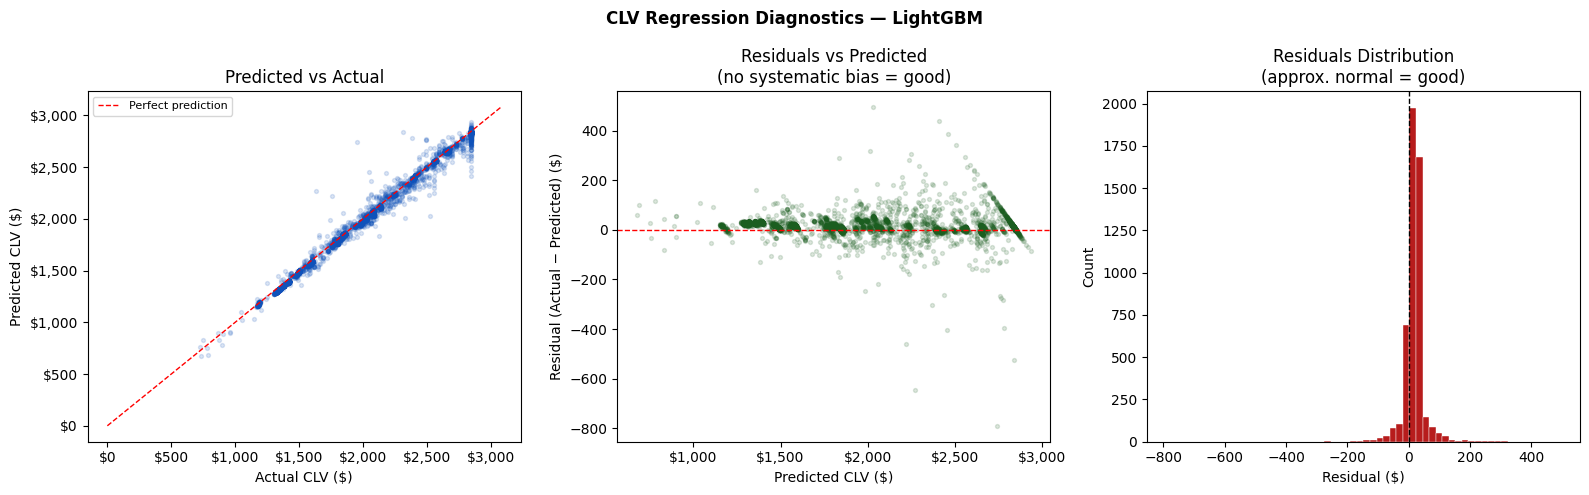

Saved: outputs/11_clv_diagnostics.png


In [12]:
# Three diagnostic plots for the best model
rng  = np.random.default_rng(42)
n_plot = min(5000, len(y_te))
idx  = rng.choice(len(y_te), n_plot, replace=False)
y_s  = y_te[idx]
yp_s = best_clv_pred[idx]
res  = y_s - yp_s

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("CLV Regression Diagnostics — %s" % best_clv_model_name,
             fontsize=12, fontweight="bold")

# Panel 1: Predicted vs Actual
ax = axes[0]
ax.scatter(y_s, yp_s, alpha=0.15, s=8, color="#0F52BA")
lim = max(y_s.max(), yp_s.max()) * 1.05
ax.plot([0, lim], [0, lim], "r--", linewidth=1, label="Perfect prediction")
ax.set_xlabel("Actual CLV ($)")
ax.set_ylabel("Predicted CLV ($)")
ax.set_title("Predicted vs Actual")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: "$%s" % f"{int(x):,}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: "$%s" % f"{int(x):,}"))

# Panel 2: Residuals vs Predicted
ax = axes[1]
ax.scatter(yp_s, res, alpha=0.15, s=8, color="#1B5E20")
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Predicted CLV ($)")
ax.set_ylabel("Residual (Actual − Predicted) ($)")
ax.set_title("Residuals vs Predicted\n(no systematic bias = good)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: "$%s" % f"{int(x):,}"))

# Panel 3: Residuals distribution
ax = axes[2]
ax.hist(res, bins=60, color="#B71C1C", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Residual ($)")
ax.set_ylabel("Count")
ax.set_title("Residuals Distribution\n(approx. normal = good)")

plt.tight_layout()
plt.savefig(OUTPUTS / "11_clv_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/11_clv_diagnostics.png")

## Section 4 — Segment CLV

Closing the narrative: **Segment → Churn Risk → CLV → Retention Priority**

In [13]:
# Load kkbox_features.parquet for original string segment_label
kkbox = pd.read_parquet(OUTPUTS / "kkbox_features.parquet")[["msno", "segment_label", "is_churn"]]

# Build test CLV predictions dataframe
test_pred_df = pd.DataFrame({
    "msno":          msno_te,
    "actual_clv":    y_te.astype(float),
    "predicted_clv": best_clv_pred.astype(float),
})

# Join with segment labels
seg_df = test_pred_df.merge(kkbox[["msno", "segment_label"]], on="msno", how="left")

seg_clv = (
    seg_df.groupby("segment_label")["predicted_clv"]
    .agg(mean_clv="mean", median_clv="median", n_customers="count")
    .reset_index()
    .sort_values("mean_clv", ascending=False)
)

print("Mean Predicted CLV by Segment (test non-churned):")
print(seg_clv.to_string(index=False))

Mean Predicted CLV by Segment (test non-churned):
   segment_label    mean_clv  median_clv  n_customers
     Power Users 2033.204671 2029.511511         4248
         Dormant 1961.418085 1841.798697          815
Casual Listeners 1899.778084 1810.953792        75027
         At-Risk 1841.448936 1588.772547        33362


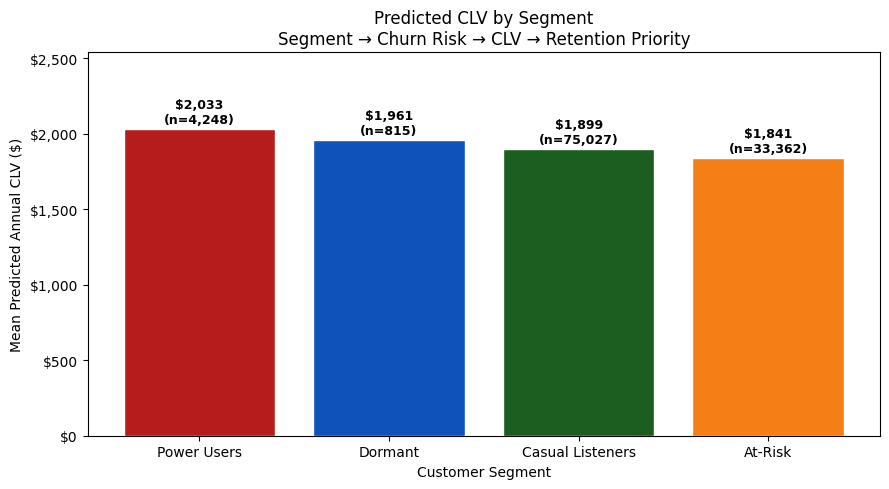

Saved: outputs/11_clv_by_segment.png

Business insight: segments with highest CLV AND high churn risk
   segment_label    mean_clv  churn_rate  priority_score
     Power Users 2033.204671    0.095276      193.716206
Casual Listeners 1899.778084    0.096305      182.957972
         At-Risk 1841.448936    0.089239      164.329269
         Dormant 1961.418085    0.055656      109.164800

(Priority score = mean_clv × churn_rate = expected revenue at risk per customer)


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
colors_seg = ["#B71C1C", "#0F52BA", "#1B5E20", "#F57F17"]
bars = ax.bar(seg_clv["segment_label"], seg_clv["mean_clv"],
              color=colors_seg[:len(seg_clv)], edgecolor="white")
for bar, row in zip(bars, seg_clv.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            "$%s\n(n=%s)" % (f"{int(row.mean_clv):,}", f"{row.n_customers:,}"),
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xlabel("Customer Segment")
ax.set_ylabel("Mean Predicted Annual CLV ($)")
ax.set_title("Predicted CLV by Segment\nSegment → Churn Risk → CLV → Retention Priority")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: "$%s" % f"{int(x):,}"))
ax.set_ylim(0, seg_clv["mean_clv"].max() * 1.25)
plt.tight_layout()
plt.savefig(OUTPUTS / "11_clv_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/11_clv_by_segment.png")

print("\nBusiness insight: segments with highest CLV AND high churn risk")
# Pull churn rates from kkbox_features for context
seg_churn = kkbox.groupby("segment_label")["is_churn"].mean().reset_index()
seg_churn.columns = ["segment_label", "churn_rate"]
summary = seg_clv.merge(seg_churn, on="segment_label")
summary["priority_score"] = summary["mean_clv"] * summary["churn_rate"]
summary = summary.sort_values("priority_score", ascending=False)
print(summary[["segment_label","mean_clv","churn_rate","priority_score"]].to_string(index=False))
print("\n(Priority score = mean_clv × churn_rate = expected revenue at risk per customer)")

## Section 5 — Save

In [15]:
joblib.dump(best_clv_model, OUTPUTS / "clv_model.pkl")

# Save predictions: msno, actual_clv, predicted_clv for all test non-churned customers
test_pred_df.to_parquet(OUTPUTS / "clv_predictions.parquet", index=False)

print("Saved:")
print("  outputs/clv_model.pkl            (%s)" % best_clv_model_name)
print("  outputs/clv_predictions.parquet  (%s test non-churned customers)" % f"{len(test_pred_df):,}")
print("  outputs/clv_model_comparison.csv")
print()
print("Summary")
print("-" * 55)
print("  Best CLV model  : %s" % best_clv_model_name)
best_row = clv_comparison.iloc[0]
print("  Test RMSE       : $%.2f" % best_row["RMSE"])
print("  Test MAE        : $%.2f" % best_row["MAE"])
print("  Test R²         : %.4f" % best_row["R2"])
print("  CLV cap (99pct) : $%.2f" % clv_cap)
print("  Non-churn test  : %s customers" % f"{len(y_te):,}")

Saved:
  outputs/clv_model.pkl            (LightGBM)
  outputs/clv_predictions.parquet  (113,452 test non-churned customers)
  outputs/clv_model_comparison.csv

Summary
-------------------------------------------------------
  Best CLV model  : LightGBM
  Test RMSE       : $47.81
  Test MAE        : $27.30
  Test R²         : 0.9923
  CLV cap (99pct) : $2848.35
  Non-churn test  : 113,452 customers
